In [23]:
import sys
import os
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling.models import custom_model
from astropy.modeling.fitting import LevMarLSQFitter
from astropy.io import fits
from astropy.table import Table
from scipy.optimize import curve_fit
from scipy.stats import norm
from matplotlib.pyplot import figure

In [24]:
df = pd.read_csv('Data/Results/targets.csv')
df.head()

,Unnamed: 0,designation,obsid,radial velocity,Equivalent width,Equivalent width uncertainty,reduced chi2
0,0,LAMOST J010133.64+051528.6,588903047,117.814850,-0.005405,-0.030583,0.852718
1,1,LAMOST J010407.98+045359.9,588905161,14.275180,-0.004424,-0.007197,1.203721
2,2,LAMOST J010648.89+050957.0,588908160,-34.126602,-0.044528,-0.009549,1.108719
3,3,LAMOST J010723.87+070347.6,588909097,55.740116,-0.019459,-0.007520,4.581556
4,4,LAMOST J010933.67+060524.1,588909130,-109.963490,-0.020388,-0.011047,0.946807


In [25]:
ew_col = "Equivalent width"
err_col = "Equivalent width uncertainty"
df["weight"] = 1 / df[err_col]**2

# weighted numerator
df["weighted_EW"] = df[ew_col] * df["weight"]

df_grouped = (
    df.groupby("designation")
    .agg(
        weighted_EW_sum=("weighted_EW", "sum"),
        weight_sum=("weight", "sum"),
        N_obs=("designation", "size"),
        mean_rv=("radial velocity", "mean"),
    )
)
df_grouped["weighted_EW"] = (
    df_grouped["weighted_EW_sum"]
    / df_grouped["weight_sum"]
)
df_grouped["weighted_EW_err"] = (
    1 / np.sqrt(df_grouped["weight_sum"])
)

df_grouped = df_grouped[
    [
        "weighted_EW",
        "weighted_EW_err",
        "mean_rv",
        "N_obs",
    ]
].reset_index()

df_grouped

,designation,weighted_EW,weighted_EW_err,mean_rv,N_obs
0,LAMOST J000045.08+062941.8,-0.228935,0.008277,-85.706842,2
1,LAMOST J000054.12+000557.2,-0.151939,0.035105,62.654655,1
2,LAMOST J000113.14+363329.4,-0.016100,0.010038,113.205157,3
3,LAMOST J000153.85+352956.9,-0.019139,0.016463,62.654655,2
4,LAMOST J000159.70+332027.8,-0.064951,0.013121,25.784543,3
...,...,...,...,...,...
3173,LAMOST J235754.04+083641.0,-0.004167,0.012901,117.970970,1
3174,LAMOST J235759.43-012526.1,-0.059018,0.015162,62.654655,1
3175,LAMOST J235823.73+064428.6,-0.002003,0.008816,104.141900,1
3176,LAMOST J235842.88+080108.3,-0.032364,0.017144,-89.242180,1


In [26]:
df_grouped['weighted_EW_log'] = np.log10(np.abs(df_grouped['weighted_EW']))
df_grouped

,designation,weighted_EW,weighted_EW_err,mean_rv,N_obs,weighted_EW_log
0,LAMOST J000045.08+062941.8,-0.228935,0.008277,-85.706842,2,-0.640287
1,LAMOST J000054.12+000557.2,-0.151939,0.035105,62.654655,1,-0.818329
2,LAMOST J000113.14+363329.4,-0.016100,0.010038,113.205157,3,-1.793167
3,LAMOST J000153.85+352956.9,-0.019139,0.016463,62.654655,2,-1.718074
4,LAMOST J000159.70+332027.8,-0.064951,0.013121,25.784543,3,-1.187411
...,...,...,...,...,...,...
3173,LAMOST J235754.04+083641.0,-0.004167,0.012901,117.970970,1,-2.380216
3174,LAMOST J235759.43-012526.1,-0.059018,0.015162,62.654655,1,-1.229017
3175,LAMOST J235823.73+064428.6,-0.002003,0.008816,104.141900,1,-2.698253
3176,LAMOST J235842.88+080108.3,-0.032364,0.017144,-89.242180,1,-1.489944


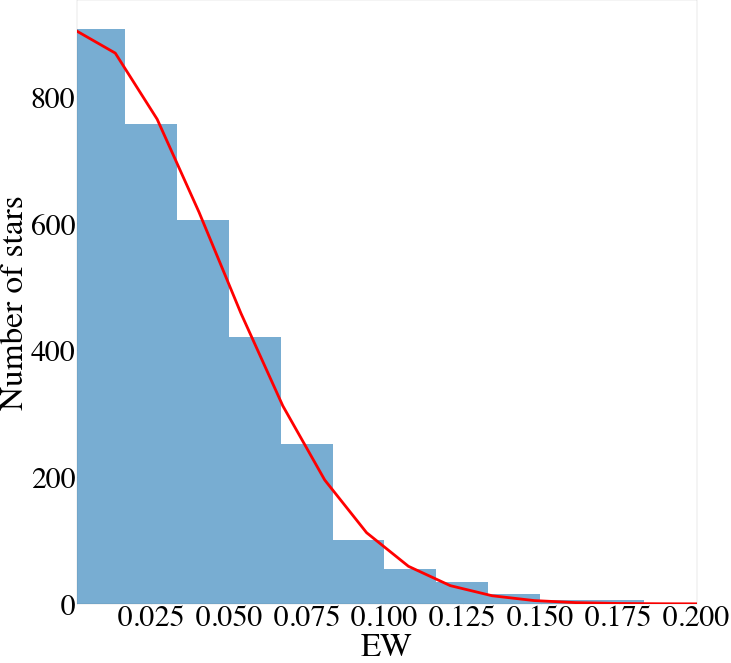

[0.00831783 0.02495272 0.04158762 0.05822251 0.07485741 0.0914923
 0.10812719 0.12476209 0.14139698 0.15803188 0.17466677 0.19130167
 0.20793656 0.22457146 0.24120635 0.25784124 0.27447614 0.29111103
 0.30774593 0.32438082 0.34101572 0.35765061 0.37428551 0.3909204
 0.40755529 0.42419019 0.44082508 0.45745998 0.47409487 0.49072977
 0.50736466 0.52399956 0.54063445 0.55726934 0.57390424 0.59053913
 0.60717403 0.62380892 0.64044382 0.65707871 0.67371361 0.6903485
 0.70698339 0.72361829 0.74025318 0.75688808 0.77352297 0.79015787
 0.80679276 0.82342765 0.84006255 0.85669744 0.87333234 0.88996723
 0.90660213 0.92323702 0.93987192 0.95650681 0.9731417  0.9897766
 1.00641149 1.02304639 1.03968128 1.05631618 1.07295107 1.08958597
 1.10622086 1.12285575 1.13949065 1.15612554 1.17276044 1.18939533
 1.20603023 1.22266512 1.23930002 1.25593491 1.2725698  1.2892047
 1.30583959 1.32247449]


<Figure size 432x288 with 0 Axes>

In [33]:
#plot the distribution and Gaussian fit for the distribution
plt.rcParams.update({'font.family':'times'})
fig= figure(figsize=(100,100),dpi=8)

data = np.absolute(np.array(df_grouped['weighted_EW']))

# Fix the mean value
fixed_mean = 0

# Define the Gaussian function with the fixed mean
@custom_model
def sum_of_gaussians(x, amplitude=1., mean=-1., sigma=1.):
	return (amplitude * np.exp(-0.5 * ((x - mean) / sigma)**2))

# Calculate the histogram data
counts, bins = np.histogram(data, bins=80, density = False)

# Calculate the bin centers
bin_centers = (bins[:-1] + bins[1:]) / 2

# Fit the Gaussian function to the histogram data
fit = LevMarLSQFitter()
m_init = sum_of_gaussians(amplitude=2000,mean=0, sigma=1)
m_init.mean.fixed = True
m_init.amplitude.fixed = False
m_init.sigma.fixed = False
m = fit(m_init, bin_centers, counts)

# Generate x values for the Gaussian fit line
x = np.linspace(min(data), max(data), 100)

# Plot the histogram
plt.hist(data, bins=80, density=False, alpha=0.6, label='Data')
# Plot the Gaussian fit
plt.plot(x, m(x), 'r', linewidth=25, label='Gaussian fit')
plt.xlabel('EW', size = 300)
plt.ylabel('Number of stars', size = 300)
plt.xticks(fontsize=270)
plt.yticks(fontsize=270)
plt.xlim(0.001, 0.2)
plt.show()
plt.savefig("/Users/mac/Desktop/cassi/Distribution of equivalent width_SDSS.png", dpi=1300, bbox_inches = 'tight')
print(bin_centers)


In [28]:
df_grouped

,designation,weighted_EW,weighted_EW_err,mean_rv,N_obs,weighted_EW_log
0,LAMOST J000045.08+062941.8,-0.228935,0.008277,-85.706842,2,-0.640287
1,LAMOST J000054.12+000557.2,-0.151939,0.035105,62.654655,1,-0.818329
2,LAMOST J000113.14+363329.4,-0.016100,0.010038,113.205157,3,-1.793167
3,LAMOST J000153.85+352956.9,-0.019139,0.016463,62.654655,2,-1.718074
4,LAMOST J000159.70+332027.8,-0.064951,0.013121,25.784543,3,-1.187411
...,...,...,...,...,...,...
3173,LAMOST J235754.04+083641.0,-0.004167,0.012901,117.970970,1,-2.380216
3174,LAMOST J235759.43-012526.1,-0.059018,0.015162,62.654655,1,-1.229017
3175,LAMOST J235823.73+064428.6,-0.002003,0.008816,104.141900,1,-2.698253
3176,LAMOST J235842.88+080108.3,-0.032364,0.017144,-89.242180,1,-1.489944


In [34]:
df_candidates = df_grouped.loc[(df_grouped['weighted_EW'] < -0.13) & (df_grouped['weighted_EW']/df_grouped['weighted_EW_err'] < -3)] 
df_candidates.to_csv('Data/Results/sample_candidates.csv')
df_candidates
# df_candidates[df_candidates["designation"] == 'LAMOST J150102.52+564015.6']

,designation,weighted_EW,weighted_EW_err,mean_rv,N_obs,weighted_EW_log
0,LAMOST J000045.08+062941.8,-0.228935,0.008277,-85.706842,2,-0.640287
1,LAMOST J000054.12+000557.2,-0.151939,0.035105,62.654655,1,-0.818329
22,LAMOST J000556.86-012835.5,-0.437247,0.011161,-34.126602,1,-0.359274
34,LAMOST J000931.30-005813.9,-0.140713,0.038370,124.885510,1,-0.851667
76,LAMOST J005251.44+104310.4,-0.370621,0.033137,539.423340,1,-0.431071
160,LAMOST J010913.68+032459.7,-0.166716,0.012066,11.254096,9,-0.778022
332,LAMOST J033412.85+584631.7,-0.185700,0.014086,33.046403,7,-0.731189
378,LAMOST J035700.17+601505.5,-0.133518,0.040718,117.814850,1,-0.874461
427,LAMOST J041912.65+563447.0,-0.144521,0.017189,40.182401,4,-0.840069
450,LAMOST J042806.13+205315.1,-0.209786,0.021598,28.081955,1,-0.678223


In [35]:
len(df_candidates)

33